### 한글 폰트 및 기본 설정

In [3]:
import warnings
import matplotlib.pyplot as plt

In [4]:
# 기본 설정
warnings.filterwarnings(action='ignore') # 경고 메시지 무시
# matplotlib 설정 변경
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 한글폰트 마이너스 표시 문제 해결

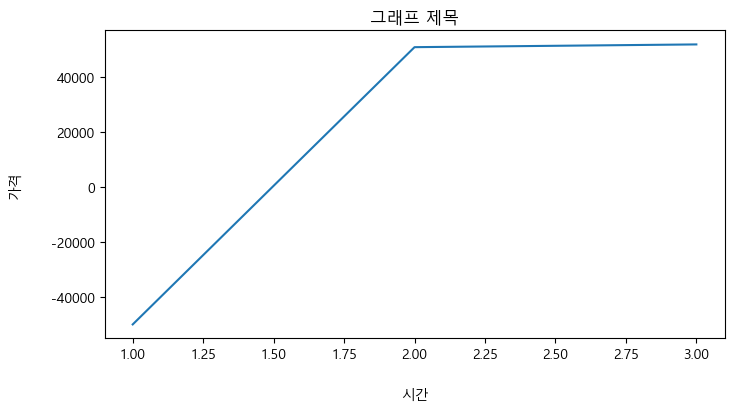

In [20]:
# 테스트 해보기
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

graph_title = '그래프 제목'
ax.set_title(f'{graph_title}')
ax.set_xlabel('시간', labelpad=20) # labelpad : 라벨과 그래프 사이의 거리
ax.set_ylabel('가격', labelpad=20)

ax.plot([1, 2, 3], [-50000, 51000, 52000])

plt.show()

# BIS

- visit BIS webpage (https://www.bis.org/statistics/dsr.htm?m=6_380_671)
- download Debt service ratios (whole data set) xlsx file

DSR 엑셀파일 구조
- Quarterly Series시트 입수
- 첫 3개 행을 제외 (그 다음 첫번째 행은 컬럼으로 자동 지정)
- 첫번째 열을 인덱스로 지정

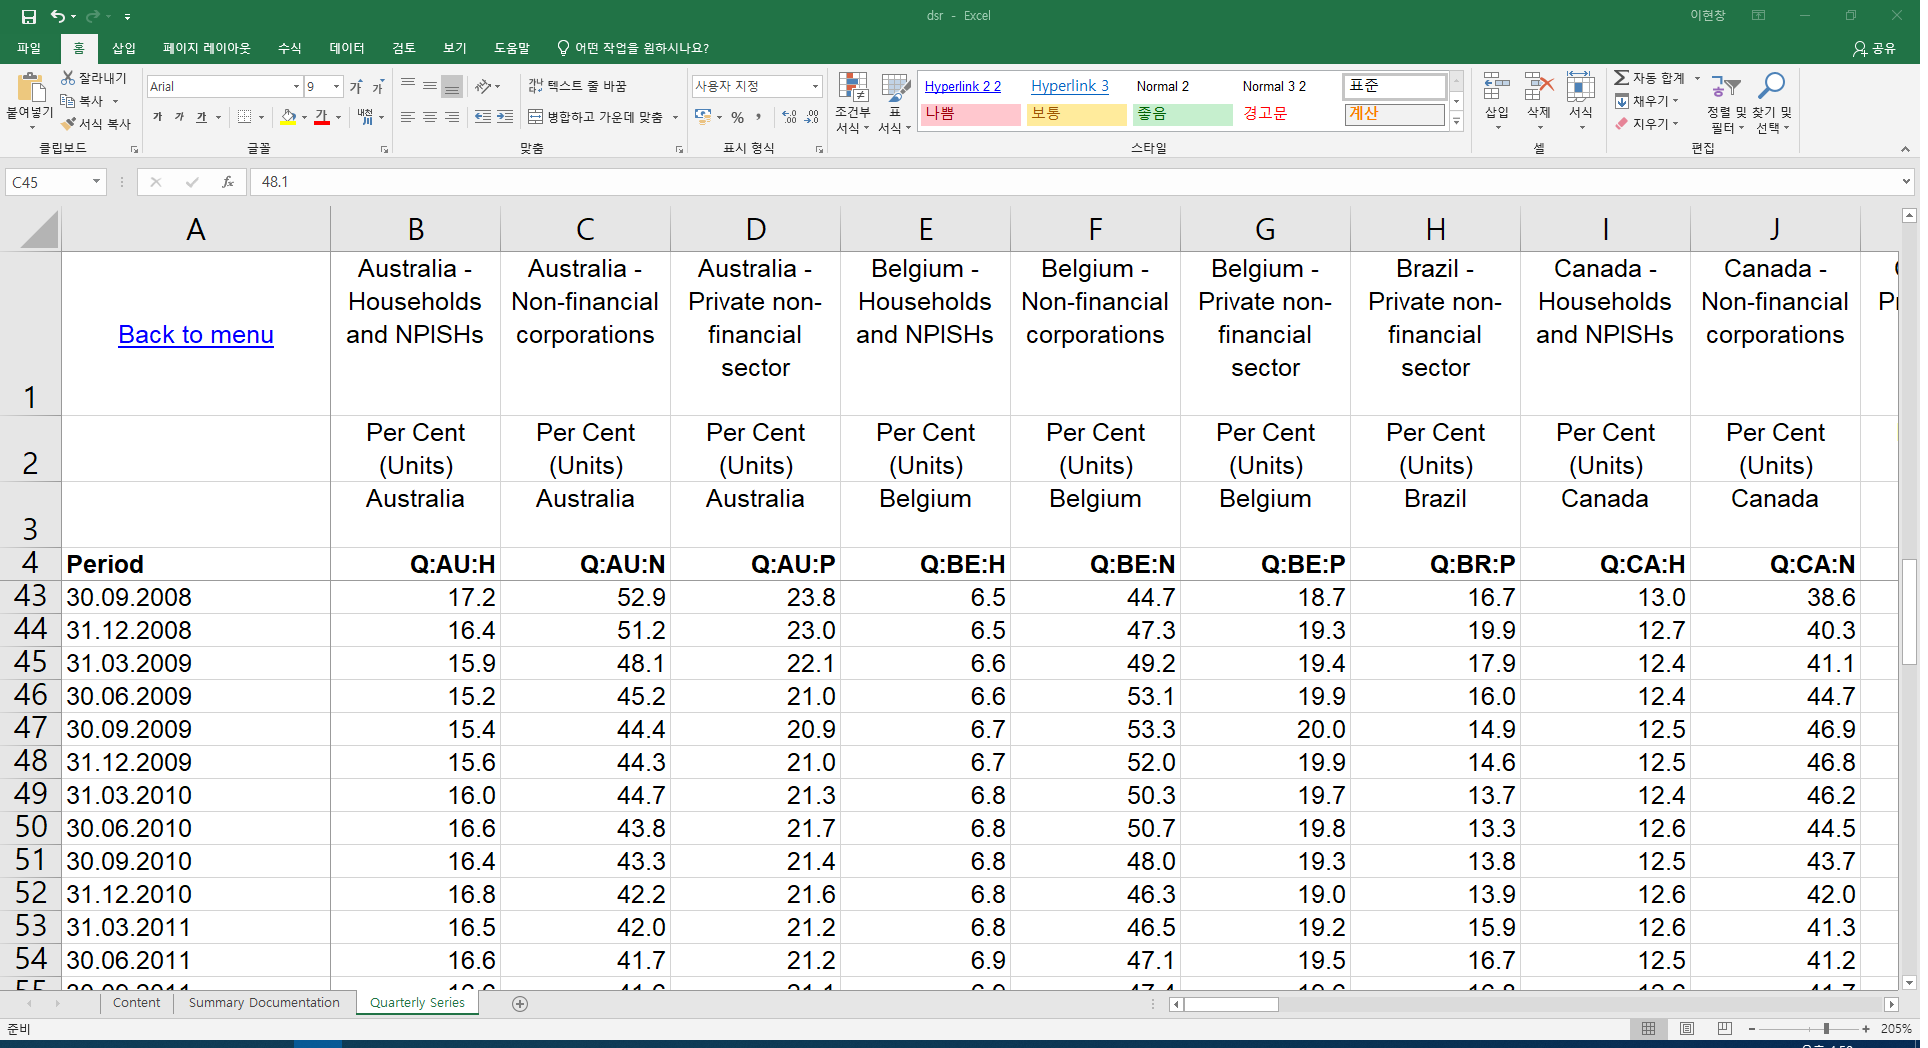

In [8]:
from IPython.display import Image
Image('data/dsr_xlsx.png', width=1000)

DSR 엑셀파일 다운로드
- Quarterly Series시트 입수 (sheet_name='Quarterly Series')
- 첫 3개 행을 제외 (그 다음 첫번째 행은 컬럼으로 자동 지정) (skiprows=3)
- 첫번째 열을 인덱스로 지정 (index_col=0)

In [9]:
import pandas as pd

In [10]:
df = pd.read_excel('data/dsr.xlsx', sheet_name='Quarterly Series', skiprows=3, index_col=0)

In [11]:
df

,Q:AU:H,Q:AU:N,Q:AU:P,Q:BE:H,Q:BE:N,Q:BE:P,Q:BR:P,Q:CA:H,Q:CA:N,Q:CA:P,...,Q:RU:P,Q:SE:H,Q:SE:N,Q:SE:P,Q:TH:P,Q:TR:P,Q:US:H,Q:US:N,Q:US:P,Q:ZA:P
Period,,,,,,,,,,,,,,,,,,,,,
1999-03-31,10.0,44.7,16.4,6.1,37.5,13.9,40.1,10.6,56.5,21.1,...,14.8,8.9,31.6,18.3,23.3,NaN,9.4,42.3,16.0,12.1
1999-06-30,10.1,43.9,16.3,6.0,38.8,14.2,32.9,10.5,54.7,20.7,...,11.4,8.9,29.3,17.0,21.0,NaN,9.5,42.6,16.2,11.9
1999-09-30,10.3,44.6,16.5,6.0,40.8,15.0,27.2,10.5,52.6,20.3,...,10.0,8.9,29.8,17.2,18.8,NaN,9.6,43.3,16.5,11.3
1999-12-31,10.5,45.3,16.9,6.0,41.9,15.4,24.2,10.5,50.3,19.8,...,9.1,9.0,30.2,17.6,17.2,NaN,9.7,43.9,16.7,10.7
2000-03-31,10.9,46.2,17.4,6.0,42.5,15.7,19.2,10.7,50.5,20.5,...,7.6,9.0,31.6,18.4,16.3,NaN,9.8,44.7,17.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-31,15.7,44.6,20.8,7.2,50.8,20.4,17.5,13.2,55.8,24.1,...,12.2,11.5,47.7,23.7,9.8,21.8,7.8,42.3,14.8,9.3
2019-06-30,15.7,43.5,20.7,7.2,49.6,20.1,17.9,13.3,55.7,24.0,...,12.1,11.5,47.1,23.6,9.8,22.6,7.8,42.6,14.8,9.1
2019-09-30,15.3,42.4,20.1,7.2,49.9,20.2,17.9,13.3,56.3,24.1,...,11.9,11.5,47.8,23.8,9.8,18.0,7.8,42.7,14.9,9.2


데이터 구조 설정

- 각 칼럼 라벨을 ':'으로 나누어 멀티인덱스로 지정 df.columns.str.split(':').tolist()
- 칼럼 첫번째 레벨은 모두 분기를 나타내는 Q이므로 제거


In [16]:
df.columns.str.split(':').tolist() # .str: 문자열 처리 메서드

[['Q', 'AU', 'H'],
 ['Q', 'AU', 'N'],
 ['Q', 'AU', 'P'],
 ['Q', 'BE', 'H'],
 ['Q', 'BE', 'N'],
 ['Q', 'BE', 'P'],
 ['Q', 'BR', 'P'],
 ['Q', 'CA', 'H'],
 ['Q', 'CA', 'N'],
 ['Q', 'CA', 'P'],
 ['Q', 'CH', 'P'],
 ['Q', 'CN', 'P'],
 ['Q', 'CZ', 'P'],
 ['Q', 'DE', 'H'],
 ['Q', 'DE', 'N'],
 ['Q', 'DE', 'P'],
 ['Q', 'DK', 'H'],
 ['Q', 'DK', 'N'],
 ['Q', 'DK', 'P'],
 ['Q', 'ES', 'H'],
 ['Q', 'ES', 'N'],
 ['Q', 'ES', 'P'],
 ['Q', 'FI', 'H'],
 ['Q', 'FI', 'N'],
 ['Q', 'FI', 'P'],
 ['Q', 'FR', 'H'],
 ['Q', 'FR', 'N'],
 ['Q', 'FR', 'P'],
 ['Q', 'GB', 'H'],
 ['Q', 'GB', 'N'],
 ['Q', 'GB', 'P'],
 ['Q', 'HK', 'P'],
 ['Q', 'HU', 'P'],
 ['Q', 'ID', 'P'],
 ['Q', 'IN', 'P'],
 ['Q', 'IT', 'H'],
 ['Q', 'IT', 'N'],
 ['Q', 'IT', 'P'],
 ['Q', 'JP', 'H'],
 ['Q', 'JP', 'N'],
 ['Q', 'JP', 'P'],
 ['Q', 'KR', 'H'],
 ['Q', 'KR', 'N'],
 ['Q', 'KR', 'P'],
 ['Q', 'MX', 'P'],
 ['Q', 'MY', 'P'],
 ['Q', 'NL', 'H'],
 ['Q', 'NL', 'N'],
 ['Q', 'NL', 'P'],
 ['Q', 'NO', 'H'],
 ['Q', 'NO', 'N'],
 ['Q', 'NO', 'P'],
 ['Q', 'PL',

라벨이 주어진 형태에 따라 멀티인덱스 생성 함수를 선택

- from_tuples() : [['16', '미국'], ['16', '한국'], ['17', '미국'], ['17', '한국']]
- from_product() : [['16', '17'], ['미국', '한국']]
- from_arrays() : [['16', '16', '17', '17'], ['미국', '미국', '한국', '한국']]

In [17]:
df.columns = pd.MultiIndex.from_tuples(df.columns.str.split(':').tolist()) # .MultiIndex.from_tuples() 함수를 사용하여 컬럼 이름을 다중 인덱스로 변환

In [18]:
df

Q                                                             \
              AU               BE                BR    CA                CH   
               H     N     P    H     N     P     P     H     N     P     P   
Period                                                                        
1999-03-31  10.0  44.7  16.4  6.1  37.5  13.9  40.1  10.6  56.5  21.1  16.9   
1999-06-30  10.1  43.9  16.3  6.0  38.8  14.2  32.9  10.5  54.7  20.7  17.1   
1999-09-30  10.3  44.6  16.5  6.0  40.8  15.0  27.2  10.5  52.6  20.3  17.1   
1999-12-31  10.5  45.3  16.9  6.0  41.9  15.4  24.2  10.5  50.3  19.8  17.0   
2000-03-31  10.9  46.2  17.4  6.0  42.5  15.7  19.2  10.7  50.5  20.5  17.2   
2000-06-30  11.6  45.3  17.9  5.9  42.3  15.9  18.8  11.0  49.9  20.6  16.8   
2000-09-30  11.5  44.9  18.0  5.8  43.1  16.2  17.5  11.0  49.7  20.8  16.9   
2000-12-31  11.6  45.6  18.1  5.8  43.4  16.4  17.5  11.1  48.5  20.3  17.0   
2001-03-31  11.3  45.4  17.8  5.7  43.1  16.3  17.2  10.9  48.8  20.3  17.2   
2001-06-30  10.8  45.0  17.1  5.6  44.9  16.6  18.3  10.7  48.2  20.3  17.3   
2001-09-30  10.9  44.4  17.1  5.5  44.7  16.6  22.6  10.5  48.1  20.1  17.1   
2001-12-31  10.7  42.5  16.6  5.4  45.4  16.7  22.6  10.3  47.8  19.9  16.8   
2002-03-31  10.8  41.7  16.4  5.4  45.4  16.8  21.9  10.1  50.0  20.3  16.8   
2002-06-30  11.5  41.7  17.1  5.4  46.8  17.0  21.4  10.1  49.8  20.0  16.8   
2002-09-30  12.0  42.3  17.5  5.5  46.3  16.7  25.5  10.2  49.6  20.1  16.6   
2002-12-31  12.2  41.9  17.7  5.5  44.9  16.4  27.3  10.4  48.8  20.1  16.5   
2003-03-31  12.4  41.1  17.8  5.5  43.6  16.2  28.9  10.2  46.1  19.3  16.5   
2003-06-30  12.6  40.0  17.8  5.5  44.3  16.3  27.0  10.4  45.4  19.4  16.5   
2003-09-30  13.0  39.1  18.0  5.5  44.4  16.4  23.5  10.6  44.4  19.3  16.4   
2003-12-31  13.3  39.2  18.2  5.5  44.8  16.6  20.5  10.6  43.2  18.9  16.3   
2004-03-31  13.9  39.0  18.7  5.5  45.3  16.9  18.3  10.7  44.6  19.5  16.2   
2004-06-30  13.9  39.6  18.7  5.5  44.9  17.0  17.9  10.8  43.5  19.3  16.0   
2004-09-30  14.2  40.9  19.1  5.5  45.4  17.2  17.4  10.8  42.9  19.3  15.8   
2004-12-31  14.3  42.5  19.4  5.6  45.8  17.3  16.8  10.8  42.1  19.1  15.6   
2005-03-31  14.4  42.9  19.5  5.6  45.4  17.2  17.4  11.1  40.7  19.0  15.8   
2005-06-30  14.6  44.7  19.9  5.7  45.4  17.2  17.7  11.2  41.4  19.6  15.7   
2005-09-30  14.9  45.4  20.3  5.8  45.0  17.1  17.8  11.4  39.2  19.0  15.7   
2005-12-31  15.1  45.9  20.6  5.8  44.2  16.9  17.6  11.4  37.3  18.6  15.5   
2006-03-31  15.1  46.2  20.8  5.9  42.9  16.7  17.4  11.7  37.9  19.0  15.5   
2006-06-30  15.5  46.7  21.3  5.9  44.3  16.8  16.7  12.0  36.3  18.5  15.3   
2006-09-30  15.9  47.8  21.9  5.9  43.3  16.8  15.9  12.2  38.0  19.2  15.6   
2006-12-31  16.3  48.6  22.4  6.0  42.8  16.8  15.9  12.3  39.6  19.6  15.5   
2007-03-31  16.4  48.9  22.5  6.1  43.1  17.0  14.6  12.4  41.5  20.1  15.8   
2007-06-30  16.4  48.9  22.6  6.1  42.3  17.2  13.2  12.6  42.3  20.5  16.1   
2007-09-30  16.8  50.8  23.3  6.2  43.5  17.5  12.5  12.9  41.7  20.4  16.3   
2007-12-31  17.0  52.2  23.7  6.3  44.4  17.9  11.9  13.1  41.2  20.6  16.8   
2008-03-31  17.2  53.9  24.1  6.3  44.6  18.2  13.8  13.1  41.0  20.5  16.8   
2008-06-30  17.6  53.9  24.4  6.4  43.6  18.3  14.3  13.1  38.8  20.0  16.8   
2008-09-30  17.2  52.9  23.8  6.5  44.7  18.7  16.7  13.0  38.6  20.0  17.0   
2008-12-31  16.4  51.2  23.0  6.5  47.3  19.3  19.9  12.7  40.3  20.3  16.9   
2009-03-31  15.9  48.1  22.1  6.6  49.2  19.4  17.9  12.4  41.1  19.7  17.1   
2009-06-30  15.2  45.2  21.0  6.6  53.1  19.9  16.0  12.4  44.7  20.4  17.4   
2009-09-30  15.4  44.4  20.9  6.7  53.3  20.0  14.9  12.5  46.9  20.6  17.6   
2009-12-31  15.6  44.3  21.0  6.7  52.0  19.9  14.6  12.5  46.8  20.5  17.7   
2010-03-31  16.0  44.7  21.3  6.8  50.3  19.7  13.7  12.4  46.2  20.6  17.7   
2010-06-30  16.6  43.8  21.7  6.8  50.7  19.8  13.3  12.6  44.5  20.3  17.3   
2010-09-30  16.4  43.3  21.4  6.8  48.0  19.3  13.8  12.5  43.7  

In [32]:
df.columns.get_level_values(0).unique()

Index(['Q'], dtype='object')

In [33]:
df.columns.get_level_values(1).unique()

Index(['AU', 'BE', 'BR', 'CA', 'CH', 'CN', 'CZ', 'DE', 'DK', 'ES', 'FI', 'FR',
       'GB', 'HK', 'HU', 'ID', 'IN', 'IT', 'JP', 'KR', 'MX', 'MY', 'NL', 'NO',
       'PL', 'PT', 'RU', 'SE', 'TH', 'TR', 'US', 'ZA'],
      dtype='object')

In [34]:
df.columns.get_level_values(2).unique()

Index(['H', 'N', 'P'], dtype='object')

In [35]:
df = df.droplevel(0, axis = 1) # df['Q']

In [36]:
df

AU               BE                BR    CA              ...  \
               H     N     P    H     N     P     P     H     N     P  ...   
Period                                                                 ...   
1999-03-31  10.0  44.7  16.4  6.1  37.5  13.9  40.1  10.6  56.5  21.1  ...   
1999-06-30  10.1  43.9  16.3  6.0  38.8  14.2  32.9  10.5  54.7  20.7  ...   
1999-09-30  10.3  44.6  16.5  6.0  40.8  15.0  27.2  10.5  52.6  20.3  ...   
1999-12-31  10.5  45.3  16.9  6.0  41.9  15.4  24.2  10.5  50.3  19.8  ...   
2000-03-31  10.9  46.2  17.4  6.0  42.5  15.7  19.2  10.7  50.5  20.5  ...   
...          ...   ...   ...  ...   ...   ...   ...   ...   ...   ...  ...   
2019-03-31  15.7  44.6  20.8  7.2  50.8  20.4  17.5  13.2  55.8  24.1  ...   
2019-06-30  15.7  43.5  20.7  7.2  49.6  20.1  17.9  13.3  55.7  24.0  ...   
2019-09-30  15.3  42.4  20.1  7.2  49.9  20.2  17.9  13.3  56.3  24.1  ...   
2019-12-31  14.9  41.0  19.7  7.2  49.4  20.1  17.5  13.3  56.2  24.1  ...   
2020-03-31  14.8  41.4  19.7  7.2  49.9  20.1  17.3  13.1  57.7  24.2  ...   

              RU    SE                TH    TR   US                ZA  
               P     H     N     P     P     P    H     N     P     P  
Period                                                                 
1999-03-31  14.8   8.9  31.6  18.3  23.3   NaN  9.4  42.3  16.0  12.1  
1999-06-30  11.4   8.9  29.3  17.0  21.0   NaN  9.5  42.6  16.2  11.9  
1999-09-30  10.0   8.9  29.8  17.2  18.8   NaN  9.6  43.3  16.5  11.3  
1999-12-31   9.1   9.0  30.2  17.6  17.2   NaN  9.7  43.9  16.7  10.7  
2000-03-31   7.6   9.0  31.6  18.4  16.3   NaN  9.8  44.7  17.0  10.0  
...          ...   ...   ...   ...   ...   ...  ...   ...   ...   ...  
2019-03-31  12.2  11.5  47.7  23.7   9.8  21.8  7.8  42.3  14.8   9.3  
2019-06-30  12.1  11.5  47.1  23.6   9.8  22.6  7.8  42.6  14.8   9.1  
2019-09-30  11.9  11.5  47.8  23.8   9.8  18.0  7.8  42.7  14.9   9.2  
2019-12-31  11.4  11.5  49.1  24.0   9.8  13.9  7.8  42.6  14.8   9.0  
2020-03-31  11.8  11.6  49.6  24.1   9.9  12.8  7.8  43.8  15.0   9.2  

[85 rows x 66 columns]

각 부문(민간, 비금융기업, 가계)에 대한 국가별 DSR 수준을 확인하기 쉽도록 칼럼 레벨 순서를 변경

- df.reorder_levels()

In [37]:
df.reorder_levels([1, 0], axis = 1)

H     N     P    H     N     P           H     N     P  ...  \
              AU    AU    AU   BE    BE    BE    BR    CA    CA    CA  ...   
Period                                                                 ...   
1999-03-31  10.0  44.7  16.4  6.1  37.5  13.9  40.1  10.6  56.5  21.1  ...   
1999-06-30  10.1  43.9  16.3  6.0  38.8  14.2  32.9  10.5  54.7  20.7  ...   
1999-09-30  10.3  44.6  16.5  6.0  40.8  15.0  27.2  10.5  52.6  20.3  ...   
1999-12-31  10.5  45.3  16.9  6.0  41.9  15.4  24.2  10.5  50.3  19.8  ...   
2000-03-31  10.9  46.2  17.4  6.0  42.5  15.7  19.2  10.7  50.5  20.5  ...   
...          ...   ...   ...  ...   ...   ...   ...   ...   ...   ...  ...   
2019-03-31  15.7  44.6  20.8  7.2  50.8  20.4  17.5  13.2  55.8  24.1  ...   
2019-06-30  15.7  43.5  20.7  7.2  49.6  20.1  17.9  13.3  55.7  24.0  ...   
2019-09-30  15.3  42.4  20.1  7.2  49.9  20.2  17.9  13.3  56.3  24.1  ...   
2019-12-31  14.9  41.0  19.7  7.2  49.4  20.1  17.5  13.3  56.2  24.1  ...   
2020-03-31  14.8  41.4  19.7  7.2  49.9  20.1  17.3  13.1  57.7  24.2  ...   

                     H     N     P                H     N     P        
              RU    SE    SE    SE    TH    TR   US    US    US    ZA  
Period                                                                 
1999-03-31  14.8   8.9  31.6  18.3  23.3   NaN  9.4  42.3  16.0  12.1  
1999-06-30  11.4   8.9  29.3  17.0  21.0   NaN  9.5  42.6  16.2  11.9  
1999-09-30  10.0   8.9  29.8  17.2  18.8   NaN  9.6  43.3  16.5  11.3  
1999-12-31   9.1   9.0  30.2  17.6  17.2   NaN  9.7  43.9  16.7  10.7  
2000-03-31   7.6   9.0  31.6  18.4  16.3   NaN  9.8  44.7  17.0  10.0  
...          ...   ...   ...   ...   ...   ...  ...   ...   ...   ...  
2019-03-31  12.2  11.5  47.7  23.7   9.8  21.8  7.8  42.3  14.8   9.3  
2019-06-30  12.1  11.5  47.1  23.6   9.8  22.6  7.8  42.6  14.8   9.1  
2019-09-30  11.9  11.5  47.8  23.8   9.8  18.0  7.8  42.7  14.9   9.2  
2019-12-31  11.4  11.5  49.1  24.0   9.8  13.9  7.8  42.6  14.8   9.0  
2020-03-31  11.8  11.6  49.6  24.1   9.9  12.8  7.8  43.8  15.0   9.2  

[85 rows x 66 columns]

칼럼을 부문 - 국가 순서로 정렬 sort_index(axis=1)

In [38]:
df.reorder_levels([1, 0], axis = 1).sort_index(axis=1)

H                                                 ...     P  \
              AU   BE    CA   DE    DK   ES   FI   FR   GB   IT  ...    NL   
Period                                                           ...         
1999-03-31  10.0  6.1  10.6  9.5  17.8  6.1  4.6  4.7  8.8  3.0  ...  23.5   
1999-06-30  10.1  6.0  10.5  9.6  17.2  5.4  4.6  4.8  8.6  2.9  ...  23.7   
1999-09-30  10.3  6.0  10.5  9.6  16.7  5.4  4.6  4.8  8.6  2.9  ...  24.1   
1999-12-31  10.5  6.0  10.5  9.6  17.7  6.1  4.7  4.8  8.9  3.2  ...  24.5   
2000-03-31  10.9  6.0  10.7  9.8  17.0  5.6  4.7  4.8  9.0  3.2  ...  24.5   
...          ...  ...   ...  ...   ...  ...  ...  ...  ...  ...  ...   ...   
2019-03-31  15.7  7.2  13.2  6.1  15.0  6.2  7.1  6.3  8.9  4.3  ...  26.1   
2019-06-30  15.7  7.2  13.3  6.1  14.9  6.2  7.1  6.3  8.9  4.2  ...  26.1   
2019-09-30  15.3  7.2  13.3  6.1  14.8  6.1  7.1  6.3  9.0  4.2  ...  26.1   
2019-12-31  14.9  7.2  13.3  6.1  14.6  6.1  7.1  6.4  9.0  4.2  ...  25.9   
2020-03-31  14.8  7.2  13.1  6.1  14.4  5.9  7.2  6.4  9.0  4.2  ...  25.8   

                                                                 
              NO   PL    PT    RU    SE    TH    TR    US    ZA  
Period                                                           
1999-03-31  23.6  8.2  14.0  14.8  18.3  23.3   NaN  16.0  12.1  
1999-06-30  23.5  7.9  14.1  11.4  17.0  21.0   NaN  16.2  11.9  
1999-09-30  23.2  7.9  14.0  10.0  17.2  18.8   NaN  16.5  11.3  
1999-12-31  23.1  7.9  14.1   9.1  17.6  17.2   NaN  16.7  10.7  
2000-03-31  22.9  8.0  14.3   7.6  18.4  16.3   NaN  17.0  10.0  
...          ...  ...   ...   ...   ...   ...   ...   ...   ...  
2019-03-31  25.9  7.0  14.6  12.2  23.7   9.8  21.8  14.8   9.3  
2019-06-30  26.4  6.9  14.5  12.1  23.6   9.8  22.6  14.8   9.1  
2019-09-30  27.0  6.9  14.3  11.9  23.8   9.8  18.0  14.9   9.2  
2019-12-31  27.3  6.8  14.1  11.4  24.0   9.8  13.9  14.8   9.0  
2020-03-31  27.9  7.0  14.1  11.8  24.1   9.9  12.8  15.0   9.2  

[85 rows x 66 columns]

데이터 자료형을 확인

In [39]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 85 entries, 1999-03-31 to 2020-03-31
Data columns (total 66 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   (AU, H)  85 non-null     float64
 1   (AU, N)  85 non-null     float64
 2   (AU, P)  85 non-null     float64
 3   (BE, H)  85 non-null     float64
 4   (BE, N)  85 non-null     float64
 5   (BE, P)  85 non-null     float64
 6   (BR, P)  85 non-null     float64
 7   (CA, H)  85 non-null     float64
 8   (CA, N)  85 non-null     float64
 9   (CA, P)  85 non-null     float64
 10  (CH, P)  85 non-null     float64
 11  (CN, P)  85 non-null     float64
 12  (CZ, P)  85 non-null     float64
 13  (DE, H)  85 non-null     float64
 14  (DE, N)  85 non-null     float64
 15  (DE, P)  85 non-null     float64
 16  (DK, H)  85 non-null     float64
 17  (DK, N)  85 non-null     float64
 18  (DK, P)  85 non-null     float64
 19  (ES, H)  85 non-null     float64
 20  (ES, N)  85 non-null     float64
 21

In [40]:
df.tail()

AU               BE                BR    CA              ...  \
               H     N     P    H     N     P     P     H     N     P  ...   
Period                                                                 ...   
2019-03-31  15.7  44.6  20.8  7.2  50.8  20.4  17.5  13.2  55.8  24.1  ...   
2019-06-30  15.7  43.5  20.7  7.2  49.6  20.1  17.9  13.3  55.7  24.0  ...   
2019-09-30  15.3  42.4  20.1  7.2  49.9  20.2  17.9  13.3  56.3  24.1  ...   
2019-12-31  14.9  41.0  19.7  7.2  49.4  20.1  17.5  13.3  56.2  24.1  ...   
2020-03-31  14.8  41.4  19.7  7.2  49.9  20.1  17.3  13.1  57.7  24.2  ...   

              RU    SE               TH    TR   US               ZA  
               P     H     N     P    P     P    H     N     P    P  
Period                                                               
2019-03-31  12.2  11.5  47.7  23.7  9.8  21.8  7.8  42.3  14.8  9.3  
2019-06-30  12.1  11.5  47.1  23.6  9.8  22.6  7.8  42.6  14.8  9.1  
2019-09-30  11.9  11.5  47.8  23.8  9.8  18.0  7.8  42.7  14.9  9.2  
2019-12-31  11.4  11.5  49.1  24.0  9.8  13.9  7.8  42.6  14.8  9.0  
2020-03-31  11.8  11.6  49.6  24.1  9.9  12.8  7.8  43.8  15.0  9.2  

[5 rows x 66 columns]

그래프 그리기

- 한국의 부문별 DSR 추이
- 한국, 미국, 영국의 가계부문 DSR 추이 (idx = pd.IndexSlice 이용)
- 2010년 이후 추이 (.loc['2010':, ])

In [42]:
df

AU               BE                BR    CA              ...  \
               H     N     P    H     N     P     P     H     N     P  ...   
Period                                                                 ...   
1999-03-31  10.0  44.7  16.4  6.1  37.5  13.9  40.1  10.6  56.5  21.1  ...   
1999-06-30  10.1  43.9  16.3  6.0  38.8  14.2  32.9  10.5  54.7  20.7  ...   
1999-09-30  10.3  44.6  16.5  6.0  40.8  15.0  27.2  10.5  52.6  20.3  ...   
1999-12-31  10.5  45.3  16.9  6.0  41.9  15.4  24.2  10.5  50.3  19.8  ...   
2000-03-31  10.9  46.2  17.4  6.0  42.5  15.7  19.2  10.7  50.5  20.5  ...   
...          ...   ...   ...  ...   ...   ...   ...   ...   ...   ...  ...   
2019-03-31  15.7  44.6  20.8  7.2  50.8  20.4  17.5  13.2  55.8  24.1  ...   
2019-06-30  15.7  43.5  20.7  7.2  49.6  20.1  17.9  13.3  55.7  24.0  ...   
2019-09-30  15.3  42.4  20.1  7.2  49.9  20.2  17.9  13.3  56.3  24.1  ...   
2019-12-31  14.9  41.0  19.7  7.2  49.4  20.1  17.5  13.3  56.2  24.1  ...   
2020-03-31  14.8  41.4  19.7  7.2  49.9  20.1  17.3  13.1  57.7  24.2  ...   

              RU    SE                TH    TR   US                ZA  
               P     H     N     P     P     P    H     N     P     P  
Period                                                                 
1999-03-31  14.8   8.9  31.6  18.3  23.3   NaN  9.4  42.3  16.0  12.1  
1999-06-30  11.4   8.9  29.3  17.0  21.0   NaN  9.5  42.6  16.2  11.9  
1999-09-30  10.0   8.9  29.8  17.2  18.8   NaN  9.6  43.3  16.5  11.3  
1999-12-31   9.1   9.0  30.2  17.6  17.2   NaN  9.7  43.9  16.7  10.7  
2000-03-31   7.6   9.0  31.6  18.4  16.3   NaN  9.8  44.7  17.0  10.0  
...          ...   ...   ...   ...   ...   ...  ...   ...   ...   ...  
2019-03-31  12.2  11.5  47.7  23.7   9.8  21.8  7.8  42.3  14.8   9.3  
2019-06-30  12.1  11.5  47.1  23.6   9.8  22.6  7.8  42.6  14.8   9.1  
2019-09-30  11.9  11.5  47.8  23.8   9.8  18.0  7.8  42.7  14.9   9.2  
2019-12-31  11.4  11.5  49.1  24.0   9.8  13.9  7.8  42.6  14.8   9.0  
2020-03-31  11.8  11.6  49.6  24.1   9.9  12.8  7.8  43.8  15.0   9.2  

[85 rows x 66 columns]

<Axes: xlabel='Period'>

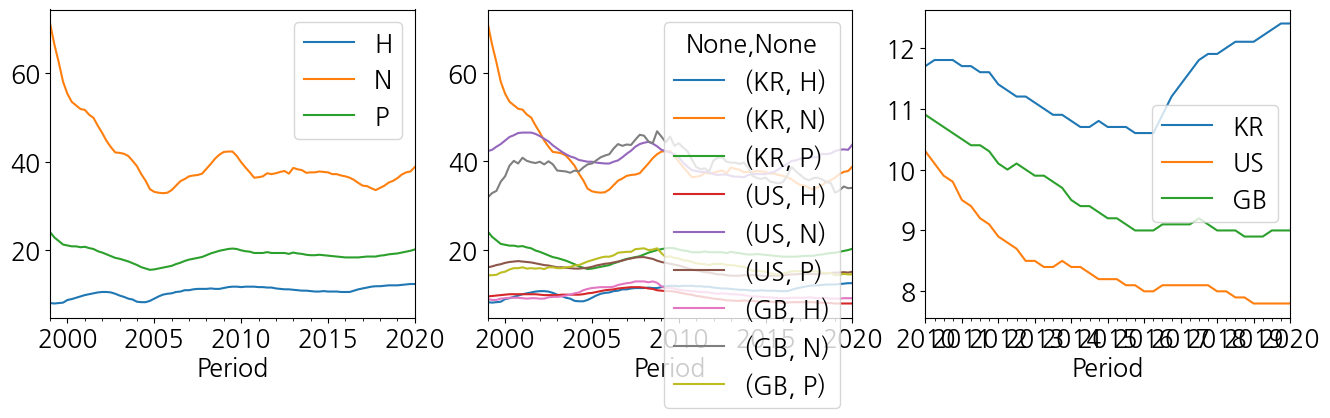

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))


df['KR'].plot(ax = ax[0])
df.loc[:, ['KR', 'US', 'GB']].plot(ax = ax[1])
df.reorder_levels([1, 0], axis = 1)['H'].loc['2010':, ['KR', 'US', 'GB']].plot(ax = ax[2])

그래프 꾸미기
- python2021/script 폴더에서 RGB 값들이 리스트로 저장된 colors.py 파일 실행
    - lcolors, bcolors
- 색 지정, 범례, 그리드, 타이틀, 마커 등

In [43]:
%run python101/script/colors.py

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.1, 'household DSR')

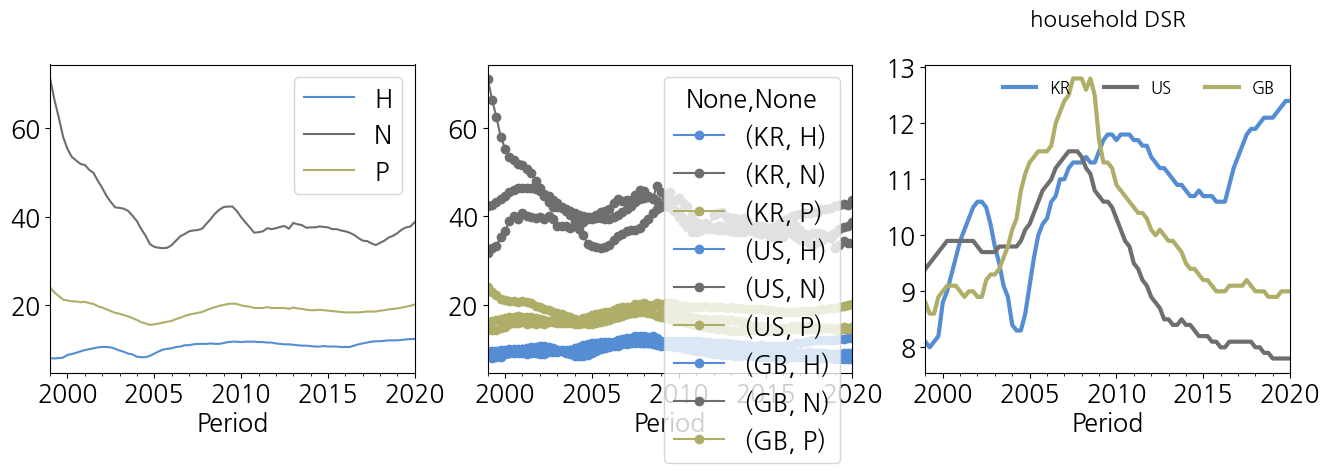

In [61]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))


df['KR'].plot(ax = ax[0], color=lcolors[:3])
df.loc[:, ['KR', 'US', 'GB']].plot(ax = ax[1], color=lcolors[:3], marker='o')
df.reorder_levels([1, 0], axis = 1)['H'].loc[:, ['KR', 'US', 'GB']].plot(ax = ax[2], lw=3, color=lcolors[:3])

ax[2].legend(ncol=3, frameon=False, fontsize=12)
ax[2].set_title('household DSR', fontsize=16, y=1.1)

연도별 그래프 그리기

- 평균, 연말, moving average

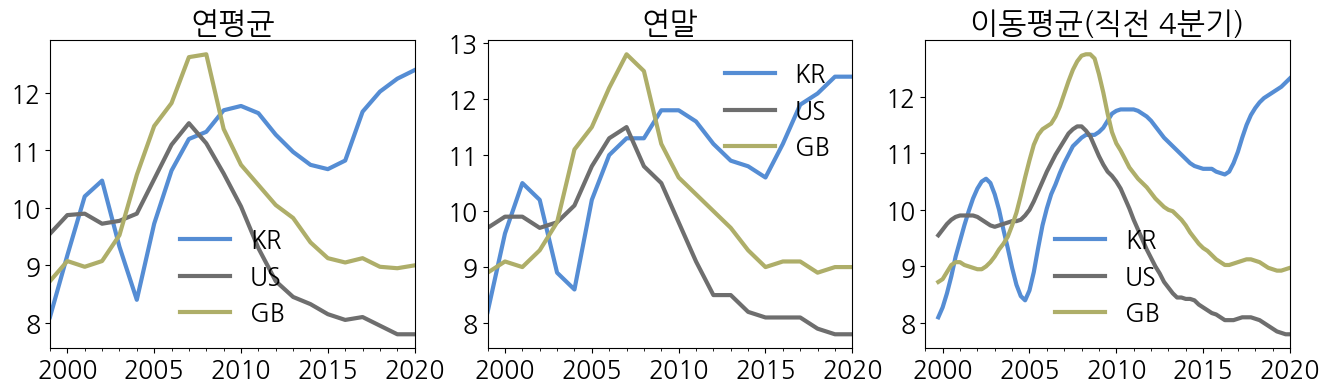

In [63]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))

df_h = df.reorder_levels([1, 0], axis = 1)['H'].loc[:, ['KR', 'US', 'GB']]
df_h.index.names = [None]

df_h.resample('A').mean().plot(ax = ax[0], lw=3, color=lcolors[:3])
df_h.resample('A').last().plot(ax = ax[1], lw=3, color=lcolors[:3])
df_h.rolling(4, center=False).mean().plot(ax = ax[2], lw=3, color=lcolors[:3])

for i, t in enumerate(['연평균', '연말', '이동평균(직전 4분기)']):
    ax[i].set_title(t)
    ax[i].legend(frameon=False)


# 한국부동산원

- 웹페이지 https://www.reb.or.kr/r-one/main.do

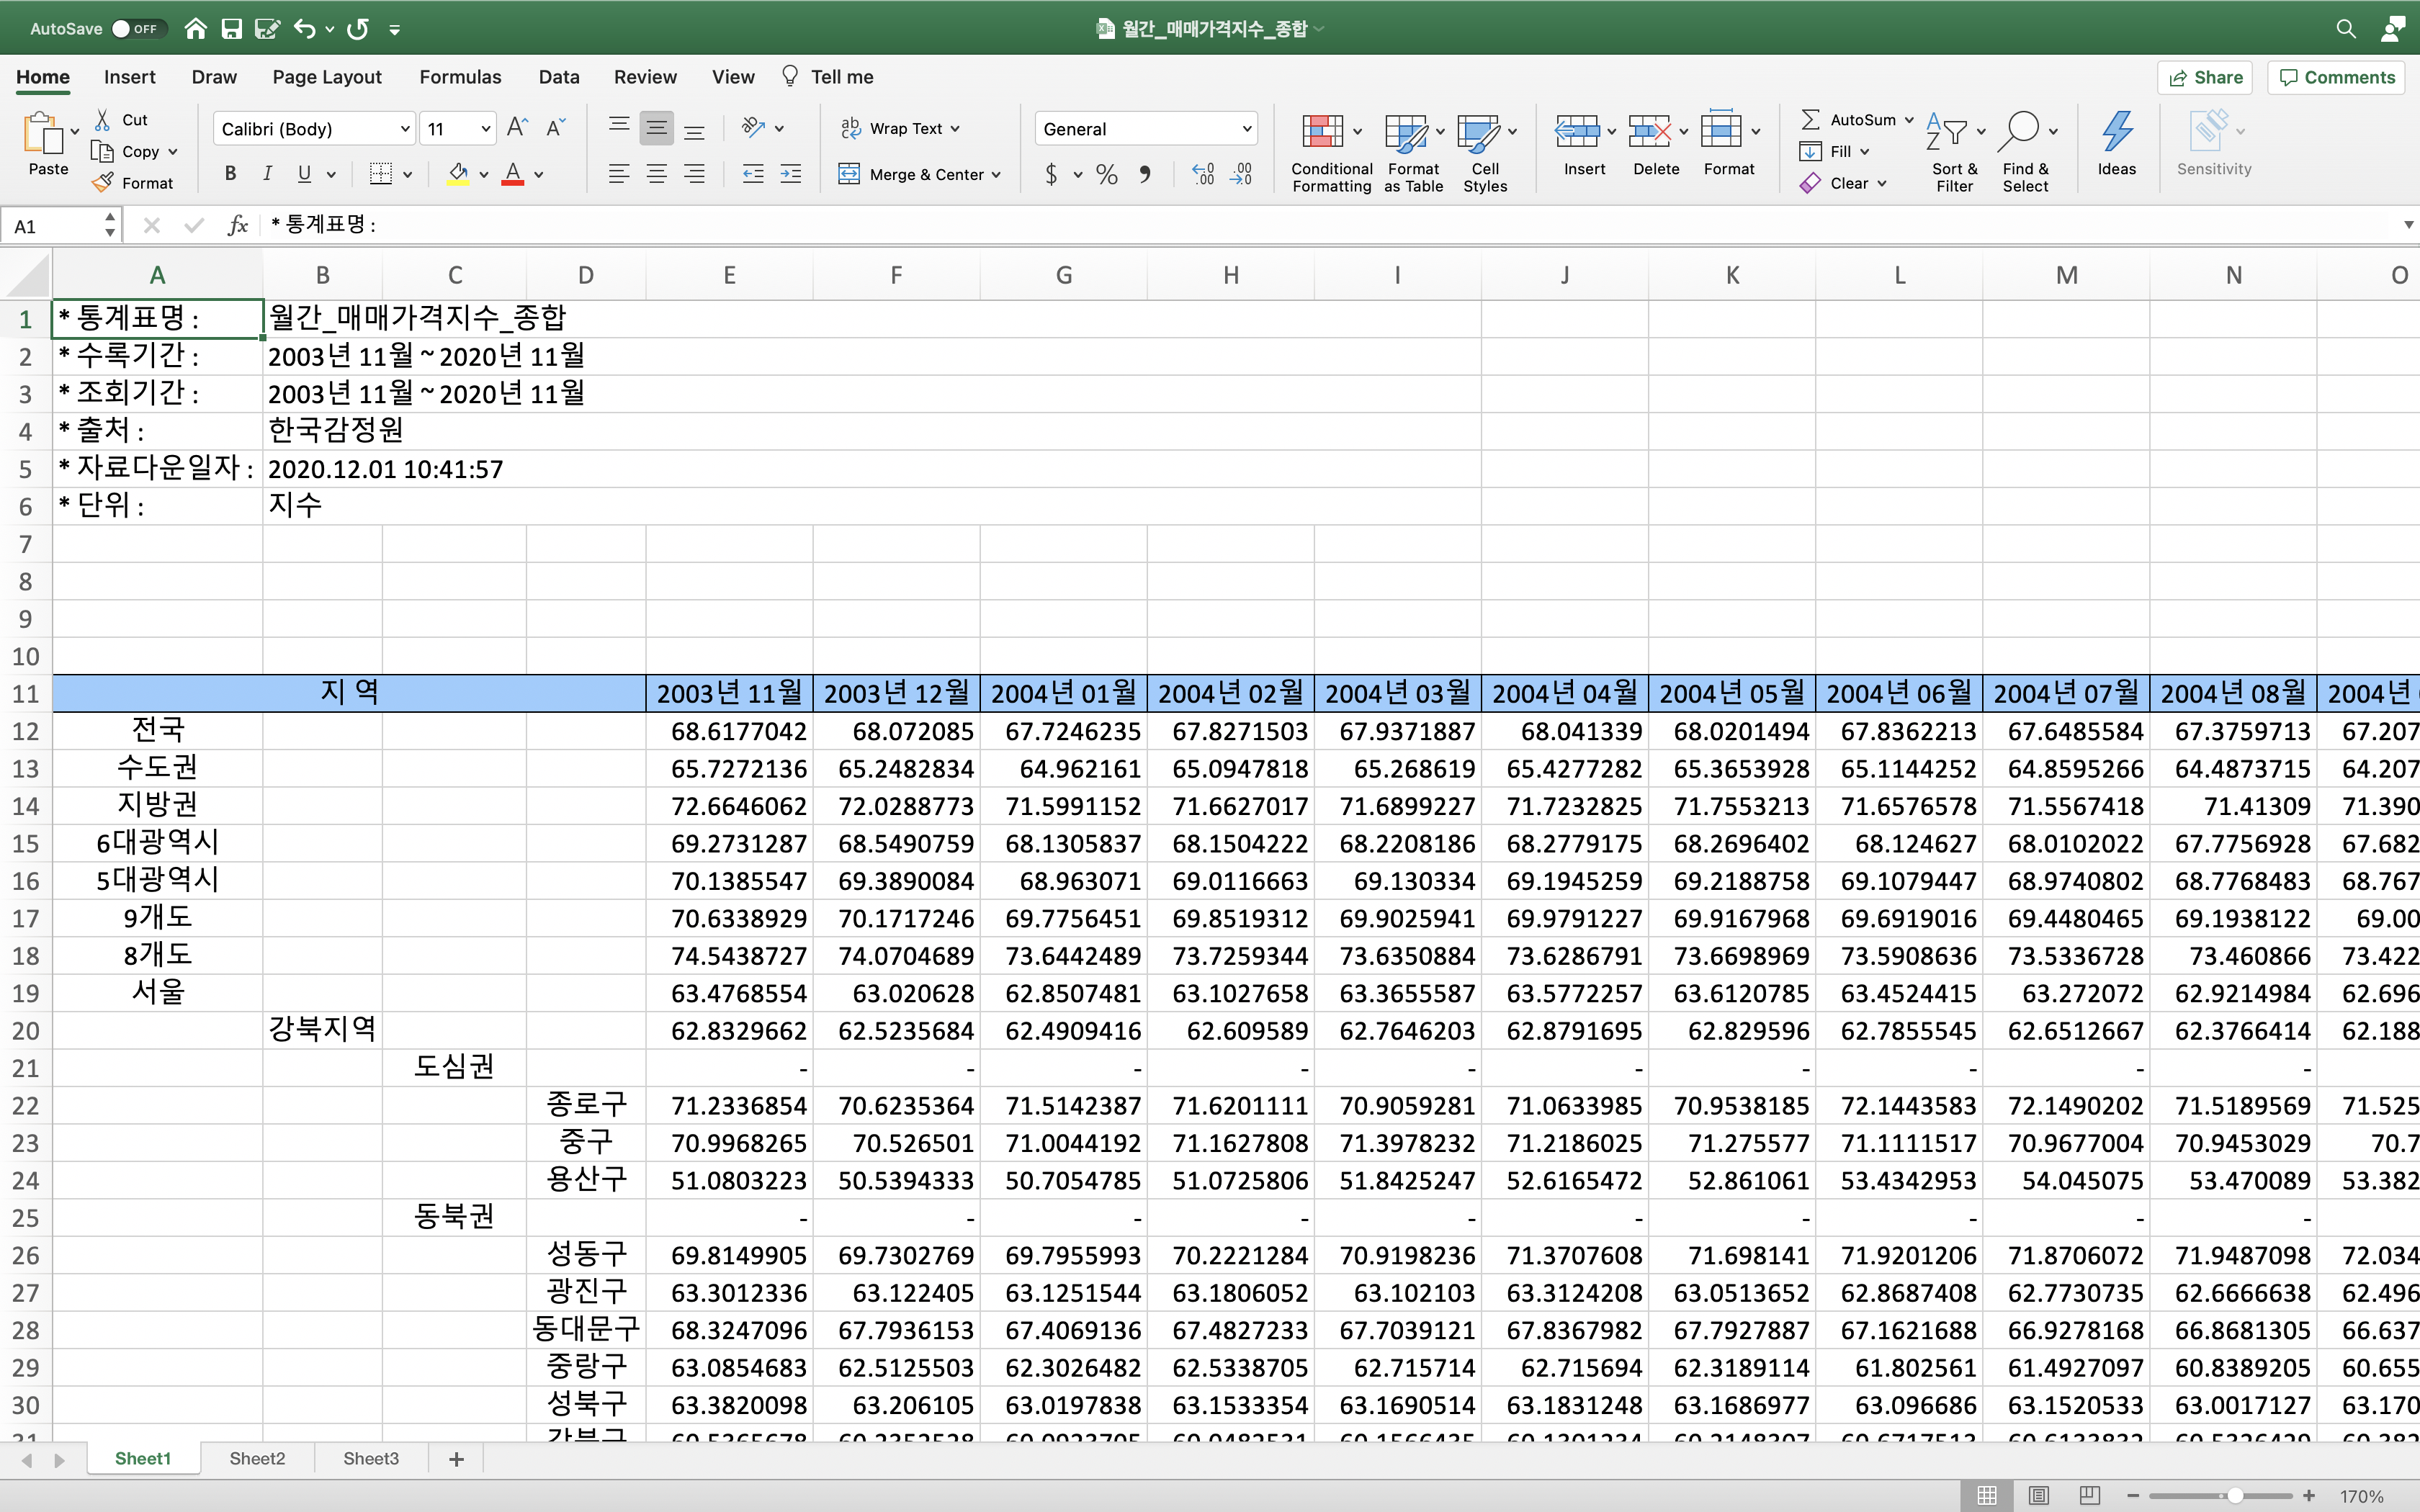

In [64]:
from IPython.display import Image

Image('python101/input/reb_xlsx.png', width=1000)

데이터 입수
- Sheet1 시트 입수
- 첫 10개 행 제외

In [66]:
df = pd.read_excel('python101/input/reb.xlsx', sheet_name='Sheet1', skiprows=10)

In [67]:
df.head(15)

,지 역,Unnamed: 1,Unnamed: 2,Unnamed: 3,2003년 11월,2003년 12월,2004년 01월,2004년 02월,2004년 03월,2004년 04월,...,2020년 02월,2020년 03월,2020년 04월,2020년 05월,2020년 06월,2020년 07월,2020년 08월,2020년 09월,2020년 10월,2020년 11월
0,전국,NaN,NaN,NaN,68.617704,68.072085,67.724623,67.82715,67.937189,68.041339,...,101.473629,102.023739,102.30141,102.439549,102.860048,103.490924,103.980226,104.419841,104.751838,105.315058
1,수도권,NaN,NaN,NaN,65.727214,65.248283,64.962161,65.094782,65.268619,65.427728,...,104.983763,105.956932,106.500467,106.767341,107.295471,108.162637,108.730402,109.200187,109.523817,110.064184
2,지방권,NaN,NaN,NaN,72.664606,72.028877,71.599115,71.662702,71.689923,71.723282,...,98.389117,98.577374,98.628994,98.65803,98.9871,99.418084,99.840749,100.254391,100.592939,101.174575
3,6대광역시,NaN,NaN,NaN,69.273129,68.549076,68.130584,68.150422,68.220819,68.277917,...,101.690027,102.269215,102.594644,102.783843,103.290726,103.756154,104.155578,104.705335,105.19987,106.121624
4,5대광역시,NaN,NaN,NaN,70.138555,69.389008,68.963071,69.011666,69.130334,69.194526,...,101.627626,101.892867,101.995889,102.061216,102.48142,102.938144,103.395693,104.038408,104.611825,105.671593
5,9개도,NaN,NaN,NaN,70.633893,70.171725,69.775645,69.851931,69.902594,69.979123,...,99.118383,99.72377,100.047827,100.225083,100.662886,101.269683,101.719912,102.105058,102.390931,102.889564
6,8개도,NaN,NaN,NaN,74.543873,74.070469,73.644249,73.725934,73.635088,73.628679,...,96.18769,96.245469,96.235305,96.23606,96.470969,96.783379,97.03524,97.236312,97.407282,97.689147
7,서울,NaN,NaN,NaN,63.476855,63.020628,62.850748,63.102766,63.365559,63.577226,...,108.708096,108.851816,108.830591,108.737396,108.878312,109.655113,110.119263,110.419274,110.596536,110.78195
8,NaN,강북지역,NaN,NaN,62.832966,62.523568,62.490942,62.609589,62.76462,62.879169,...,108.001469,108.24648,108.337449,108.327749,108.454405,109.226095,109.739937,110.092041,110.316839,110.545971
9,NaN,NaN,도심권,NaN,-,-,-,-,-,-,...,110.436115,110.611923,110.628382,110.601511,110.729517,111.241389,111.632766,111.935565,112.115223,112.328064


지역 이름 정리
- 전국, 수도권, 지방권, 6대광역시, 5대광역시, 9개도, 8개도, 서울, 서울-강북지역, 서울-도심권, 서울-종로구, ... 등
- '지역' 라벨을 아래 방향으로 채움 df.iloc[:, 0].fillna(method='ffill', axis=0)
- 첫 4개 칼럼의 NaN을 빈 문자열로 대체 df.iloc[:, 0:4].fillna('')
- 첫 4개 칼럼을 '-'으로 결함하여 새로운 칼럼 생성 df.iloc[:, 0:4].agg('-'.join, axis=1)
- '지역1-지역2' 유형 이외의 '-' 제거

In [68]:
df.iloc[:, 0] = df.iloc[:, 0].fillna(method = 'ffill', axis = 0)

In [69]:
df.iloc[:, 0:4] = df.iloc[:, 0:4].fillna('')

In [73]:
df.head(15)

,지 역,Unnamed: 1,Unnamed: 2,Unnamed: 3,2003년 11월,2003년 12월,2004년 01월,2004년 02월,2004년 03월,2004년 04월,...,2020년 02월,2020년 03월,2020년 04월,2020년 05월,2020년 06월,2020년 07월,2020년 08월,2020년 09월,2020년 10월,2020년 11월
0,전국,,,,68.617704,68.072085,67.724623,67.82715,67.937189,68.041339,...,101.473629,102.023739,102.30141,102.439549,102.860048,103.490924,103.980226,104.419841,104.751838,105.315058
1,수도권,,,,65.727214,65.248283,64.962161,65.094782,65.268619,65.427728,...,104.983763,105.956932,106.500467,106.767341,107.295471,108.162637,108.730402,109.200187,109.523817,110.064184
2,지방권,,,,72.664606,72.028877,71.599115,71.662702,71.689923,71.723282,...,98.389117,98.577374,98.628994,98.65803,98.9871,99.418084,99.840749,100.254391,100.592939,101.174575
3,6대광역시,,,,69.273129,68.549076,68.130584,68.150422,68.220819,68.277917,...,101.690027,102.269215,102.594644,102.783843,103.290726,103.756154,104.155578,104.705335,105.19987,106.121624
4,5대광역시,,,,70.138555,69.389008,68.963071,69.011666,69.130334,69.194526,...,101.627626,101.892867,101.995889,102.061216,102.48142,102.938144,103.395693,104.038408,104.611825,105.671593
5,9개도,,,,70.633893,70.171725,69.775645,69.851931,69.902594,69.979123,...,99.118383,99.72377,100.047827,100.225083,100.662886,101.269683,101.719912,102.105058,102.390931,102.889564
6,8개도,,,,74.543873,74.070469,73.644249,73.725934,73.635088,73.628679,...,96.18769,96.245469,96.235305,96.23606,96.470969,96.783379,97.03524,97.236312,97.407282,97.689147
7,서울,,,,63.476855,63.020628,62.850748,63.102766,63.365559,63.577226,...,108.708096,108.851816,108.830591,108.737396,108.878312,109.655113,110.119263,110.419274,110.596536,110.78195
8,서울,강북지역,,,62.832966,62.523568,62.490942,62.609589,62.76462,62.879169,...,108.001469,108.24648,108.337449,108.327749,108.454405,109.226095,109.739937,110.092041,110.316839,110.545971
9,서울,,도심권,,-,-,-,-,-,-,...,110.436115,110.611923,110.628382,110.601511,110.729517,111.241389,111.632766,111.935565,112.115223,112.328064


In [74]:
df['R'] = df.iloc[:, 0:4].agg('-'.join, axis=1) # agg(): 데이터프레임의 열의 집계연산을 수행하기 위한 함수. df.agg('mean'), df.agg(['mean', 'sum'])

In [75]:
df['R']

0          전국---
1         수도권---
2         지방권---
3       6대광역시---
4       5대광역시---
         ...    
223     경남-거제시--
224     경남-양산시--
225        제주---
226     제주-제주시--
227    제주-서귀포시--
Name: R, Length: 228, dtype: object

In [76]:
df['R'] = df['R'].str.rstrip('-')

In [79]:
df['R']

0           전국
1          수도권
2          지방권
3        6대광역시
4        5대광역시
        ...   
223     경남-거제시
224     경남-양산시
225         제주
226     제주-제주시
227    제주-서귀포시
Name: R, Length: 228, dtype: object

In [80]:
df['R'] = df['R'].str.replace('---', '-').str.replace('--', '-')

In [81]:
df['R'].head(15)

0          전국
1         수도권
2         지방권
3       6대광역시
4       5대광역시
5         9개도
6         8개도
7          서울
8     서울-강북지역
9      서울-도심권
10     서울-종로구
11      서울-중구
12     서울-용산구
13     서울-동북권
14     서울-성동구
Name: R, dtype: object

In [ ]:
df['R'].unique()

array(['전국', '수도권', '지방권', '6대광역시', '5대광역시', '9개도', '8개도', '서울',
       '서울-강북지역', '서울-도심권', '서울-종로구', '서울-중구', '서울-용산구', '서울-동북권',
       '서울-성동구', '서울-광진구', '서울-동대문구', '서울-중랑구', '서울-성북구', '서울-강북구',
       '서울-도봉구', '서울-노원구', '서울-서북권', '서울-은평구', '서울-서대문구', '서울-마포구',
       '서울-강남지역', '서울-서남권', '서울-양천구', '서울-강서구', '서울-구로구', '서울-금천구',
       '서울-영등포구', '서울-동작구', '서울-관악구', '서울-동남권', '서울-서초구', '서울-강남구',
       '서울-송파구', '서울-강동구', '경기', '경기-경부1권', '경기-과천시', '경기-안양시', '경기-만안구',
       '경기-동안구', '경기-성남시', '경기-수정구', '경기-중원구', '경기-분당구', '경기-군포시',
       '경기-의왕시', '경기-경부2권', '경기-안성시', '경기-용인시', '경기-처인구', '경기-기흥구',
       '경기-수지구', '경기-수원시', '경기-장안구', '경기-권선구', '경기-팔달구', '경기-영통구',
       '경기-서해안권', '경기-부천시', '경기-안산시', '경기-상록구', '경기-단원구', '경기-시흥시',
       '경기-광명시', '경기-화성시', '경기-오산시', '경기-평택시', '경기-동부1권', '경기-남양주시',
       '경기-구리시', '경기-하남시', '경기-광주시', '경기-동부2권', '경기-이천시', '경기-여주시',
       '경기-경의권', '경기-김포시', '경기-고양시', '경기-덕양구', '경기-일산동구', '경기-일산서구',
       '경기-파주시', '경기-경원권', '경기-포천시', '경기-동두천시'

In [82]:
df

,지 역,Unnamed: 1,Unnamed: 2,Unnamed: 3,2003년 11월,2003년 12월,2004년 01월,2004년 02월,2004년 03월,2004년 04월,...,2020년 03월,2020년 04월,2020년 05월,2020년 06월,2020년 07월,2020년 08월,2020년 09월,2020년 10월,2020년 11월,R
0,전국,,,,68.617704,68.072085,67.724623,67.82715,67.937189,68.041339,...,102.023739,102.30141,102.439549,102.860048,103.490924,103.980226,104.419841,104.751838,105.315058,전국
1,수도권,,,,65.727214,65.248283,64.962161,65.094782,65.268619,65.427728,...,105.956932,106.500467,106.767341,107.295471,108.162637,108.730402,109.200187,109.523817,110.064184,수도권
2,지방권,,,,72.664606,72.028877,71.599115,71.662702,71.689923,71.723282,...,98.577374,98.628994,98.65803,98.9871,99.418084,99.840749,100.254391,100.592939,101.174575,지방권
3,6대광역시,,,,69.273129,68.549076,68.130584,68.150422,68.220819,68.277917,...,102.269215,102.594644,102.783843,103.290726,103.756154,104.155578,104.705335,105.19987,106.121624,6대광역시
4,5대광역시,,,,70.138555,69.389008,68.963071,69.011666,69.130334,69.194526,...,101.892867,101.995889,102.061216,102.48142,102.938144,103.395693,104.038408,104.611825,105.671593,5대광역시
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,경남,거제시,,,49.338324,51.335809,50.926889,52.829644,53.710648,53.616574,...,82.439693,82.359544,82.218803,82.189345,82.790701,83.074988,83.178192,83.191118,82.942282,경남-거제시
224,경남,양산시,,,71.000725,69.899066,69.618905,69.500128,69.674401,69.868392,...,95.601377,95.460383,95.372065,95.286078,95.184425,94.868434,94.803575,94.933949,95.118865,경남-양산시
225,제주,,,,98.494929,98.452457,93.789393,91.836958,87.98395,87.386914,...,97.501271,97.215558,96.941172,96.71273,96.572757,96.477005,96.392664,96.284012,96.224416,제주
226,제주,제주시,,,101.135734,101.092122,96.304034,94.299252,90.342939,89.729895,...,97.108594,96.845631,96.584617,96.380495,96.255999,96.179247,96.12884,96.05557,96.004039,제주-제주시


자주 사용하는 지역 리스트 만들기

In [84]:
m6 = ['부산', '대구', '인천', '광주', '대전', '울산']
p8 = ['강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주']
sma = ['서울', '경기', '인천']
nsm = ['부산', '대구', '광주', '대전', '울산', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주', '세종']
a4 = ['전국', '수도권', '6대광역시', '8개도']

r17_long = ['강원도', '경기도', '경상남도', '경상북도', '광주광역시', '대구광역시',
            '대전광역시', '부산광역시', '서울특별시', '세종특별자치시', '울산광역시',
            '인천광역시', '전라남도', '전라북도', '제주특별자치도', '충청남도', '충청북도']
r17_short = ['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산',
             '서울', '세종', '울산', '인천', '전남', '전북', '제주', '충남', '충북']
r17_en = ['GW', 'GG', 'GN', 'GB', 'GJ', 'DG', 'DJ', 'BS',
          'SE', 'SJ', 'US', 'IC', 'JN', 'JB', 'JJ', 'CN', 'CB']
r17_long2short = dict(zip(r17_long, r17_short))
r17_kr2en = dict(zip(r17_short, r17_en))

새로운 지역 이름(R)을 인덱스로 지정하고 기존 지역 이름 칼럼 제거

In [85]:
df = df.set_index('R')

In [86]:
df = df.iloc[:, 4:]

칼럼 라벨을 데이트타임인덱스로 변환하고, 시간x변수명 구조를 갖도록 transpose
- '년 ' -> '-'
- '월' -> '' (빈문자열)
- df.columns = pd.to_datetime(df.columns)
- df = df.T

In [87]:
df.head(1)

,2003년 11월,2003년 12월,2004년 01월,2004년 02월,2004년 03월,2004년 04월,2004년 05월,2004년 06월,2004년 07월,2004년 08월,...,2020년 02월,2020년 03월,2020년 04월,2020년 05월,2020년 06월,2020년 07월,2020년 08월,2020년 09월,2020년 10월,2020년 11월
R,,,,,,,,,,,,,,,,,,,,,
전국,68.617704,68.072085,67.724623,67.82715,67.937189,68.041339,68.020149,67.836221,67.648558,67.375971,...,101.473629,102.023739,102.30141,102.439549,102.860048,103.490924,103.980226,104.419841,104.751838,105.315058


In [88]:
df.columns = df.columns.str.replace('년 ', '-')

In [89]:
df.columns = df.columns.str.replace('월', '')

In [90]:
df.columns = pd.to_datetime(df.columns)

In [91]:
df = df.T

In [92]:
df

R,전국,수도권,지방권,6대광역시,5대광역시,9개도,8개도,서울,서울-강북지역,서울-도심권,...,경남-진주시,경남-통영시,경남-사천시,경남-김해시,경남-밀양시,경남-거제시,경남-양산시,제주,제주-제주시,제주-서귀포시
2003-11-01,68.617704,65.727214,72.664606,69.273129,70.138555,70.633893,74.543873,63.476855,62.832966,-,...,76.320188,-,-,70.198215,-,49.338324,71.000725,98.494929,101.135734,-
2003-12-01,68.072085,65.248283,72.028877,68.549076,69.389008,70.171725,74.070469,63.020628,62.523568,-,...,76.572567,-,-,70.338107,-,51.335809,69.899066,98.452457,101.092122,-
2004-01-01,67.724623,64.962161,71.599115,68.130584,68.963071,69.775645,73.644249,62.850748,62.490942,-,...,76.178095,-,-,70.529537,-,50.926889,69.618905,93.789393,96.304034,-
2004-02-01,67.82715,65.094782,71.662702,68.150422,69.011666,69.851931,73.725934,63.102766,62.609589,-,...,76.678682,-,-,70.401127,-,52.829644,69.500128,91.836958,94.299252,-
2004-03-01,67.937189,65.268619,71.689923,68.220819,69.130334,69.902594,73.635088,63.365559,62.76462,-,...,77.220733,-,-,70.738761,-,53.710648,69.674401,87.98395,90.342939,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-07-01,103.490924,108.162637,99.418084,103.756154,102.938144,101.269683,96.783379,109.655113,109.226095,111.241389,...,94.623397,94.830763,95.484947,88.136157,102.190338,82.790701,95.184425,96.572757,96.255999,97.375416
2020-08-01,103.980226,108.730402,99.840749,104.155578,103.395693,101.719912,97.03524,110.119263,109.739937,111.632766,...,94.791177,94.95663,95.395162,88.079918,102.181017,83.074988,94.868434,96.477005,96.179247,97.233733
2020-09-01,104.419841,109.200187,100.254391,104.705335,104.038408,102.105058,97.236312,110.419274,110.092041,111.935565,...,94.92982,95.123666,95.309113,87.950815,102.086712,83.178192,94.803575,96.392664,96.12884,97.067474
2020-10-01,104.751838,109.523817,100.592939,105.19987,104.611825,102.390931,97.407282,110.596536,110.316839,112.115223,...,95.177515,95.211612,95.244409,87.790224,101.989613,83.191118,94.933949,96.284012,96.05557,96.873497


데이터프레임 자료형이 정수나 실수인지 확인
- int, float
- str
- object

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 205 entries, 2003-11-01 to 2020-11-01
Columns: 228 entries, 전국 to 제주-서귀포시
dtypes: object(228)
memory usage: 366.8+ KB


In [93]:
df.astype(float)

ValueError: could not convert string to float: '-'

null값인 '-' 문자열을 넘파이 빈값 np.nan으로 대체

In [94]:
import numpy as np

df = df.replace('-', np.nan)

In [95]:
df.astype(float)

R,전국,수도권,지방권,6대광역시,5대광역시,9개도,8개도,서울,서울-강북지역,서울-도심권,...,경남-진주시,경남-통영시,경남-사천시,경남-김해시,경남-밀양시,경남-거제시,경남-양산시,제주,제주-제주시,제주-서귀포시
2003-11-01,68.617704,65.727214,72.664606,69.273129,70.138555,70.633893,74.543873,63.476855,62.832966,NaN,...,76.320188,NaN,NaN,70.198215,NaN,49.338324,71.000725,98.494929,101.135734,NaN
2003-12-01,68.072085,65.248283,72.028877,68.549076,69.389008,70.171725,74.070469,63.020628,62.523568,NaN,...,76.572567,NaN,NaN,70.338107,NaN,51.335809,69.899066,98.452457,101.092122,NaN
2004-01-01,67.724623,64.962161,71.599115,68.130584,68.963071,69.775645,73.644249,62.850748,62.490942,NaN,...,76.178095,NaN,NaN,70.529537,NaN,50.926889,69.618905,93.789393,96.304034,NaN
2004-02-01,67.827150,65.094782,71.662702,68.150422,69.011666,69.851931,73.725934,63.102766,62.609589,NaN,...,76.678682,NaN,NaN,70.401127,NaN,52.829644,69.500128,91.836958,94.299252,NaN
2004-03-01,67.937189,65.268619,71.689923,68.220819,69.130334,69.902594,73.635088,63.365559,62.764620,NaN,...,77.220733,NaN,NaN,70.738761,NaN,53.710648,69.674401,87.983950,90.342939,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-07-01,103.490924,108.162637,99.418084,103.756154,102.938144,101.269683,96.783379,109.655113,109.226095,111.241389,...,94.623397,94.830763,95.484947,88.136157,102.190338,82.790701,95.184425,96.572757,96.255999,97.375416
2020-08-01,103.980226,108.730402,99.840749,104.155578,103.395693,101.719912,97.035240,110.119263,109.739937,111.632766,...,94.791177,94.956630,95.395162,88.079918,102.181017,83.074988,94.868434,96.477005,96.179247,97.233733
2020-09-01,104.419841,109.200187,100.254391,104.705335,104.038408,102.105058,97.236312,110.419274,110.092041,111.935565,...,94.929820,95.123666,95.309113,87.950815,102.086712,83.178192,94.803575,96.392664,96.128840,97.067474
2020-10-01,104.751838,109.523817,100.592939,105.199870,104.611825,102.390931,97.407282,110.596536,110.316839,112.115223,...,95.177515,95.211612,95.244409,87.790224,101.989613,83.191118,94.933949,96.284012,96.055570,96.873497


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 205 entries, 2003-11-01 to 2020-11-01
Columns: 228 entries, 전국 to 제주-서귀포시
dtypes: float64(228)
memory usage: 366.8 KB


지역별 주택가격 추이
- 비수도권 광역시도 가격지수, 상승률
- 서울지역 가격지수
- 17개 광역시도중 지난 5년간 가격상승률이 가장 높은 지역 가격지수

In [97]:
df17 = df[r17_short]
df17.pct_change(60).iloc[-1, :].nlargest(5)

R
세종    0.445484
대전    0.252583
서울    0.169143
경기    0.128578
전남    0.106237
Name: 2020-11-01 00:00:00, dtype: float64

In [99]:
big5 = df17.pct_change(60).iloc[-1, :].nlargest(5).index

In [100]:
big5

Index(['세종', '대전', '서울', '경기', '전남'], dtype='object', name='R')

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


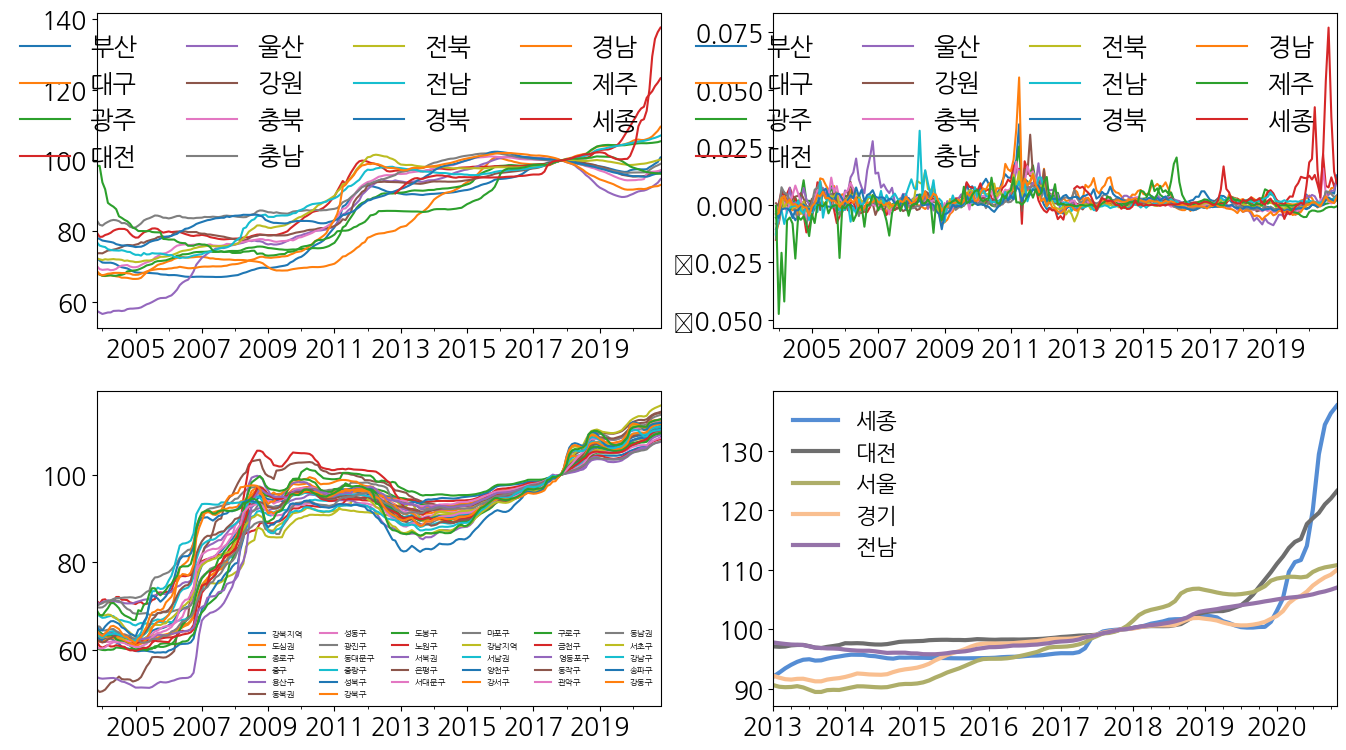

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 9))

df[nsm].plot(ax=ax[0, 0])
ax[0,0].legend(ncol=4, frameon=False)

df[nsm].pct_change().plot(ax=ax[0, 1])
ax[0,1].legend(ncol=4, frameon=False)

df.filter(like='서울').plot(ax=ax[1, 0])
seoul = df.filter(like='서울-').columns
legend = [j for i,j in seoul.str.split('-').tolist()]
ax[1,0].legend(legend, ncol=6, frameon=False, fontsize=6)

df.loc['2013':, big5].plot(ax=ax[1, 1], lw=3, color=lcolors)
ax[1,1].legend(ncol=1, frameon=False, fontsize=16)

# ECOS open API
- https://ecos.bok.or.kr/api/#/
- 회원가입 후, '서비스 이용 - 인증키 신청'
    - 아래 url에서 your_auth_key 부분을 인증키로 대체
- '개발 가이드 - 언어별 개발 가이드 - 파이썬' 참고
- '개발 가이드 - 통계코드검색'에서 원하는 통계항목의 코드 검색

'1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)'

- 인증키를 이용하여 2010년부터 2020년까지, 10,000개 이내 자료를 국문 json 파일 형식으로 입수하기 위한 url 주소 생성

ecos open api웹페이지에서 인증키 복사

In [ ]:
your_auth_key = "xxxxxxxxxxxx"

In [101]:
your_auth_key = "65Z2IWGVND8T02SR7B1M"

In [103]:
url = f'http://ecos.bok.or.kr/api/StatisticSearch/{your_auth_key}/json/kr/1/10000/102Y004/A/2010/2100/ABA1/?/?/'

In [104]:
import json
from urllib.request import urlopen

result = urlopen(url)
data = json.loads(result.read()) # 지정된 URL에서 JSON 형식의 데이터를 가져와서 Python의 데이터 구조로 변환하는 과정(파싱)

In [105]:
type(data)

dict

In [106]:
data.keys() # 딕셔너리의 키값

dict_keys(['StatisticSearch'])

In [107]:
data = data['StatisticSearch']

In [108]:
data.keys()

dict_keys(['list_total_count', 'row'])

In [109]:
data['list_total_count']

14

In [110]:
data['row']

[{'STAT_CODE': '102Y004',
  'STAT_NAME': '1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)',
  'ITEM_CODE1': 'ABA1',
  'ITEM_NAME1': '본원통화(평잔,계절조정계열)',
  'ITEM_CODE2': None,
  'ITEM_NAME2': None,
  'ITEM_CODE3': None,
  'ITEM_NAME3': None,
  'ITEM_CODE4': None,
  'ITEM_NAME4': None,
  'UNIT_NAME': '십억원 ',
  'WGT': None,
  'TIME': '2010',
  'DATA_VALUE': '67585.1'},
 {'STAT_CODE': '102Y004',
  'STAT_NAME': '1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)',
  'ITEM_CODE1': 'ABA1',
  'ITEM_NAME1': '본원통화(평잔,계절조정계열)',
  'ITEM_CODE2': None,
  'ITEM_NAME2': None,
  'ITEM_CODE3': None,
  'ITEM_NAME3': None,
  'ITEM_CODE4': None,
  'ITEM_NAME4': None,
  'UNIT_NAME': '십억원 ',
  'WGT': None,
  'TIME': '2011',
  'DATA_VALUE': '75232'},
 {'STAT_CODE': '102Y004',
  'STAT_NAME': '1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)',
  'ITEM_CODE1': 'ABA1',
  'ITEM_NAME1': '본원통화(평잔,계절조정계열)',
  'ITEM_CODE2': None,
  'ITEM_NAME2': None,
  'ITEM_CODE3': None,
  'ITEM_NAME3': None,
  'ITEM_CODE4': None,
  'ITEM_NAME4': None,
  'UNIT_NAME': '십억원 ',
  'WGT'

In [111]:
data = data['row']

In [112]:
data

[{'STAT_CODE': '102Y004',
  'STAT_NAME': '1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)',
  'ITEM_CODE1': 'ABA1',
  'ITEM_NAME1': '본원통화(평잔,계절조정계열)',
  'ITEM_CODE2': None,
  'ITEM_NAME2': None,
  'ITEM_CODE3': None,
  'ITEM_NAME3': None,
  'ITEM_CODE4': None,
  'ITEM_NAME4': None,
  'UNIT_NAME': '십억원 ',
  'WGT': None,
  'TIME': '2010',
  'DATA_VALUE': '67585.1'},
 {'STAT_CODE': '102Y004',
  'STAT_NAME': '1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)',
  'ITEM_CODE1': 'ABA1',
  'ITEM_NAME1': '본원통화(평잔,계절조정계열)',
  'ITEM_CODE2': None,
  'ITEM_NAME2': None,
  'ITEM_CODE3': None,
  'ITEM_NAME3': None,
  'ITEM_CODE4': None,
  'ITEM_NAME4': None,
  'UNIT_NAME': '십억원 ',
  'WGT': None,
  'TIME': '2011',
  'DATA_VALUE': '75232'},
 {'STAT_CODE': '102Y004',
  'STAT_NAME': '1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)',
  'ITEM_CODE1': 'ABA1',
  'ITEM_NAME1': '본원통화(평잔,계절조정계열)',
  'ITEM_CODE2': None,
  'ITEM_NAME2': None,
  'ITEM_CODE3': None,
  'ITEM_NAME3': None,
  'ITEM_CODE4': None,
  'ITEM_NAME4': None,
  'UNIT_NAME': '십억원 ',
  'WGT'

딕셔너리 데이터를 이용하여 판다스 데이터프레임 생성

In [115]:
import pandas as pd

df = pd.DataFrame(data)

In [116]:
df

,STAT_CODE,STAT_NAME,ITEM_CODE1,ITEM_NAME1,ITEM_CODE2,ITEM_NAME2,ITEM_CODE3,ITEM_NAME3,ITEM_CODE4,ITEM_NAME4,UNIT_NAME,WGT,TIME,DATA_VALUE
0,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2010,67585.1
1,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2011,75232
2,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2012,82131.1
3,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2013,91379.4
4,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2014,103331.4
5,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2015,120691.4
6,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2016,137441.5
7,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2017,151858.1
8,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2018,164963.2
9,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",ABA1,"본원통화(평잔,계절조정계열)",None,None,None,None,None,None,십억원,None,2019,178948.7


In [117]:
df = df.set_index('TIME')
df = df['DATA_VALUE'] # df가 시리즈로 추출

In [118]:
type(df)

pandas.core.series.Series

In [119]:
df.index = pd.to_datetime(df.index)
df.index.names = ['Dates']
df = df.to_frame('DATA_VALUE')
df

,DATA_VALUE
Dates,
2010-01-01,67585.1
2011-01-01,75232
2012-01-01,82131.1
2013-01-01,91379.4
2014-01-01,103331.4
2015-01-01,120691.4
2016-01-01,137441.5
2017-01-01,151858.1
2018-01-01,164963.2


In [120]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.index = pd.to_datetime(df.index)
df

,DATA_VALUE
Dates,
2010-01-01,67585.1
2011-01-01,75232
2012-01-01,82131.1
2013-01-01,91379.4
2014-01-01,103331.4
2015-01-01,120691.4
2016-01-01,137441.5
2017-01-01,151858.1
2018-01-01,164963.2


In [ ]:
from pandas.tseries.offsets import YearEnd, QuarterEnd, MonthEnd, YearBegin, QuarterBegin, MonthBegin
import json
from urllib.request import urlopen
import pandas as pd


def necos(code = '102Y004', item1 = 'ABA1', item2 = '?', item3 = '?',
         freq = 'A', first = None, last = None, N = '10000',
         detail = True, col = None):

    if first is None:
        if (freq == 'M'):
            first = '190001'
            last = '210012'
        elif (freq == 'Q'):
            first = '1900Q1'
            last = '2100Q4'
        elif (freq == 'A'):
            first = '1900'
            last = '2100'
        elif (freq == 'D'):
            first = '20200101'
            last = '20301231'
            print('Data is being retreived from 2020-01-01.')
        else:
            print('freq must be one of D, M, Q, A.')
            return

    '''retreive monthly, quarterly, annul time series from ecos.
    run 'open_ecosapi() to explore ecos api codes.'''
    ecos_key = f"http://ecos.bok.or.kr/api/StatisticSearch/{your_auth_key}"

    url  = f"{ecos_key}/json/kr/1/{N}/{code}/{freq}/{first}/{last}/{item1}/{item2}/{item3}/"
    result = urlopen(url)
    data = json.loads(result.read())
    data = data["StatisticSearch"]["row"]
    df = pd.DataFrame(data)

    if detail: # 데이터 정보 프린트
        print(f"통계: {df.loc[0, 'STAT_NAME']}",
            f"단위: {df.loc[0, 'UNIT_NAME']}",
            f"기간: {df.loc[0, 'TIME']} - {df.loc[df.index[-1], 'TIME']}",
            f"항목: {df.loc[0, 'ITEM_NAME1']}",)

    df = df.set_index("TIME")
    df.index.names = ['DATE']

    if (freq == 'M'):
        df.index = pd.to_datetime(df.index, format='%Y%m')
    elif (freq == 'Q'):
        df.index = pd.to_datetime(df.index)
    elif (freq == 'A'):
        df.index = pd.to_datetime(df.index, format='%Y')
    elif (freq == 'D'):
        df.index = pd.to_datetime(df.index, format='%Y%m%d')

    df["DATA_VALUE"] = df["DATA_VALUE"].astype("float")

    return df['DATA_VALUE'].to_frame(col)

In [ ]:
cash = necos('102Y001', 'ABA203', freq='M', col = 'cash')

통계: 1.1.1.1.4. 본원통화 구성내역(말잔, 원계열) 단위: 십억원  기간: 200201 - 202309 항목: 현금통화


In [ ]:
cash

,cash
DATE,
2002-01-01,16376.8
2002-02-01,17389.5
2002-03-01,17109.0
2002-04-01,16836.6
2002-05-01,16652.6
...,...
2023-05-01,164967.3
2023-06-01,165164.1
2023-07-01,165393.7


In [ ]:
kospi = necos('802Y001', '0001000', freq='D', col = '코스피')

Data is being retreived from 2020-01-01.
통계: 1.5.1.1. 주식시장(일) 단위: 1980.01.04=100  기간: 20200102 - 20231128 항목: KOSPI지수


In [ ]:
kospi

,코스피
DATE,
2020-01-02,2175.17
2020-01-03,2176.46
2020-01-06,2155.07
2020-01-07,2175.54
2020-01-08,2151.31
...,...
2023-11-22,2511.70
2023-11-23,2514.96
2023-11-24,2496.63


In [ ]:
plt.rcParams['axes.unicode_minus'] = False # 폰트가 한글인 경우, - 표시 오류 수정

<Axes: xlabel='DATE'>

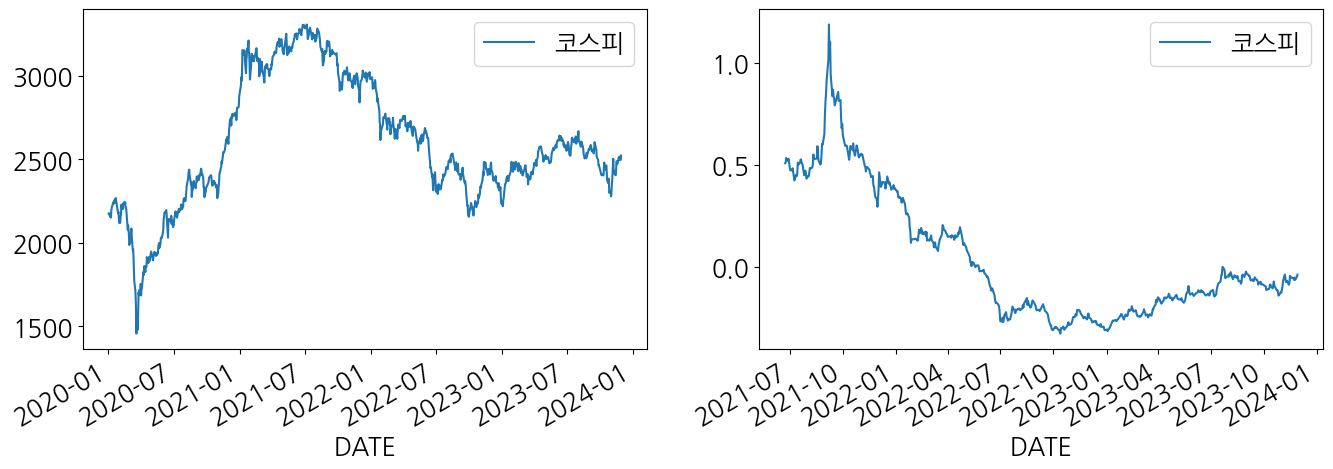

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

kospi.plot(ax=ax[0])
kospi.pct_change(365).plot(ax=ax[1])



# 퍼플릭 데이터 리더: 공공 데이터 자동 조회 파이썬 라이브러리
- https://github.com/WooilJeong/PublicDataReader

In [121]:
!pip install PublicDataReader --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 13.7 MB/s eta 0:00:00


In [124]:
from PublicDataReader import Ecos # Kosis, ...
service_key = "65Z2IWGVND8T02SR7B1M" #9VLJ7SA4HWP47YS4O04U"
api = Ecos(service_key)
df = api.get_statistic_word(용어="생산자물가지수")
df.head()

,용어,용어설명
0,생산자물가지수,국내생산자가 국내시장에 공급하는 상품 및 서비스의 가격변동을 측정하는 통계로서 경기...


In [ ]:
dir(api) # 객체가 가진 속성과 메서드의 이름을 리스트 형태로 반환

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'base_url',
 'get_key_statistic_list',
 'get_statistic_item_list',
 'get_statistic_meta',
 'get_statistic_search',
 'get_statistic_table_list',
 'get_statistic_word',
 'service_key',
 'translate']

In [ ]:
df = api.get_statistic_table_list()
df.head()

,상위통계표코드,통계표코드,통계명,시점,검색가능여부,출처
0,*,0000000001,1. 통화/금융,None,N,None
1,0000000001,0000000002,1.1. 통화/유동성,None,N,None
2,0000000002,0000000003,1.1.1. 본원통화,None,N,None
3,0000000003,0000000004,1.1.1.1. 본원통화 구성내역,None,N,None
4,0000000004,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",M,Y,None


In [ ]:
df = api.get_key_statistic_list()
df

,통계그룹명,통계명,값,시점,단위
0,시장금리,한국은행 기준금리,3.5,20231126,%
1,시장금리,콜금리(익일물),3.581,20231128,%
2,시장금리,KORIBOR(3개월),4.01,20231128,%
3,시장금리,CD수익률(91일),3.84,20231128,%
4,시장금리,통안증권수익률(364일),3.671,20231128,%
...,...,...,...,...,...
95,부동산 가격,주택매매가격지수,96.2,202310,2021.6=100
96,부동산 가격,주택전세가격지수,92.1,202310,2021.6=100
97,부동산 가격,지가변동률(전기대비),0.128,202309,%
98,원자재,"국제유가(Dubai, 현물)",86.66,202310,달러


In [ ]:
dir(api) # 객체가 가진 속성과 메서드의 이름을 리스트 형태로 반환

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'base_url',
 'get_key_statistic_list',
 'get_statistic_item_list',
 'get_statistic_meta',
 'get_statistic_search',
 'get_statistic_table_list',
 'get_statistic_word',
 'service_key',
 'translate']

In [ ]:
df = api.get_statistic_table_list()
df.head()

,상위통계표코드,통계표코드,통계명,시점,검색가능여부,출처
0,*,0000000001,1. 통화/금융,None,N,None
1,0000000001,0000000002,1.1. 통화/유동성,None,N,None
2,0000000002,0000000003,1.1.1. 본원통화,None,N,None
3,0000000003,0000000004,1.1.1.1. 본원통화 구성내역,None,N,None
4,0000000004,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",M,Y,None


In [ ]:
# 통계 테이블 리스트에서 통계명에 물가 문자열이 있는 변수 찾기
df.loc[df['통계명'].str.contains('물가')]

,상위통계표코드,통계표코드,통계명,시점,검색가능여부,출처
466,*,0000000202,4. 물가,None,N,None
467,0000000202,0000000203,4.1. 생산자물가지수(2015=100),None,N,None
468,0000000203,0000000204,4.1.1. 생산자물가지수,None,N,None
469,0000000204,404Y014,4.1.1.1. 생산자물가지수(기본분류),M,Y,None
470,0000000204,404Y015,4.1.1.2. 생산자물가지수(특수분류),M,Y,None
471,0000000204,404Y016,4.1.1.3. 생산자물가지수(품목별),M,Y,None
472,0000000204,404Y017,4.1.1.4. 생산자물가지수-총지수(1910~1964),M,Y,한국은행
473,0000000203,405Y006,4.1.2. 국내공급물가지수,M,Y,None
474,0000000203,405Y007,4.1.3. 총산출물가지수,M,Y,None
475,0000000202,0000000211,4.2. 소비자물가지수(2020=100),None,N,None


In [ ]:
df.loc[df['통계명'].str.contains('뉴스심리지수')]

,상위통계표코드,통계표코드,통계명,시점,검색가능여부,출처
653,0000000283,521Y001,6.4. 뉴스심리지수(실험적 통계),D,Y,None


In [ ]:
df = api.get_statistic_item_list(통계표코드="902Y007", translate = True) # translate 디폴트는 True
df.head()

,통계표코드,통계명,항목그룹코드,항목그룹명,통계항목코드,통계항목명,상위통계항목코드,상위통계항목명,시점,수록시작일자,수록종료일자,자료수,단위,가중치
0,902Y007,9.1.2.1. 국제 주요국 생산자물가지수,Group1,계정항목,KR,한국,None,None,A,1965,2021,57,2010=100,None
1,902Y007,9.1.2.1. 국제 주요국 생산자물가지수,Group1,계정항목,KR,한국,None,None,M,196501,202204,688,2010=100,None
2,902Y007,9.1.2.1. 국제 주요국 생산자물가지수,Group1,계정항목,KR,한국,None,None,Q,1965Q1,2022Q1,229,2010=100,None
3,902Y007,9.1.2.1. 국제 주요국 생산자물가지수,Group1,계정항목,AU,호주,None,None,A,1968,2020,53,2010=100,None
4,902Y007,9.1.2.1. 국제 주요국 생산자물가지수,Group1,계정항목,AU,호주,None,None,M,200101,202102,242,2010=100,None


In [ ]:
df = api.get_statistic_search(통계표코드="901Y009", 주기="M", 검색시작일자="201501", 검색종료일자="202312")
df.head()

,통계표코드,통계명,통계항목코드1,통계항목명1,통계항목코드2,통계항목명2,통계항목코드3,통계항목명3,통계항목코드4,통계항목명4,단위,시점,값
0,901Y009,4.2.1. 소비자물가지수,0,총지수,None,None,None,None,None,None,2020=100,201501,94.643
1,901Y009,4.2.1. 소비자물가지수,A,식료품 및 비주류음료,None,None,None,None,None,None,2020=100,201501,87.795
2,901Y009,4.2.1. 소비자물가지수,A01,식료품,None,None,None,None,None,None,2020=100,201501,87.239
3,901Y009,4.2.1. 소비자물가지수,A011,빵 및 곡물,None,None,None,None,None,None,2020=100,201501,88.351
4,901Y009,4.2.1. 소비자물가지수,A01101,쌀,None,None,None,None,None,None,2020=100,201501,86.179


In [ ]:
df = api.get_statistic_search(통계표코드="901Y009", 주기="M", 검색시작일자="201501", 검색종료일자="202312", 통계항목코드1='0')

In [ ]:
df.head()

,통계표코드,통계명,통계항목코드1,통계항목명1,통계항목코드2,통계항목명2,통계항목코드3,통계항목명3,통계항목코드4,통계항목명4,단위,시점,값
0,901Y009,4.2.1. 소비자물가지수,0,총지수,None,None,None,None,None,None,2020=100,201501,94.643
1,901Y009,4.2.1. 소비자물가지수,0,총지수,None,None,None,None,None,None,2020=100,201502,94.587
2,901Y009,4.2.1. 소비자물가지수,0,총지수,None,None,None,None,None,None,2020=100,201503,94.596
3,901Y009,4.2.1. 소비자물가지수,0,총지수,None,None,None,None,None,None,2020=100,201504,94.625
4,901Y009,4.2.1. 소비자물가지수,0,총지수,None,None,None,None,None,None,2020=100,201505,94.89


In [ ]:
df['값'] = df['값'].astype(float)

In [ ]:
type(df['값'].iloc[0])

numpy.float64

In [ ]:
df['시점'] = pd.to_datetime(df['시점'], format ='%Y%m')

In [ ]:
df_inf = pd.concat([df['시점'], df['값']], axis = 1)

In [ ]:
df_inf = df_inf.set_index('시점')
df_inf

,값
시점,
2015-01-01,94.643
2015-02-01,94.587
2015-03-01,94.596
2015-04-01,94.625
2015-05-01,94.890
...,...
2023-06-01,111.120
2023-07-01,111.200
2023-08-01,112.330


In [ ]:
df_inf.index.names = [None]
df_inf

,값
2015-01-01,94.643
2015-02-01,94.587
2015-03-01,94.596
2015-04-01,94.625
2015-05-01,94.890
...,...
2023-06-01,111.120
2023-07-01,111.200
2023-08-01,112.330
2023-09-01,112.990


In [ ]:
df_inf = df_inf.rename(columns = {'값':'cpi'})
df_inf

,cpi
2015-01-01,94.643
2015-02-01,94.587
2015-03-01,94.596
2015-04-01,94.625
2015-05-01,94.890
...,...
2023-06-01,111.120
2023-07-01,111.200
2023-08-01,112.330
2023-09-01,112.990


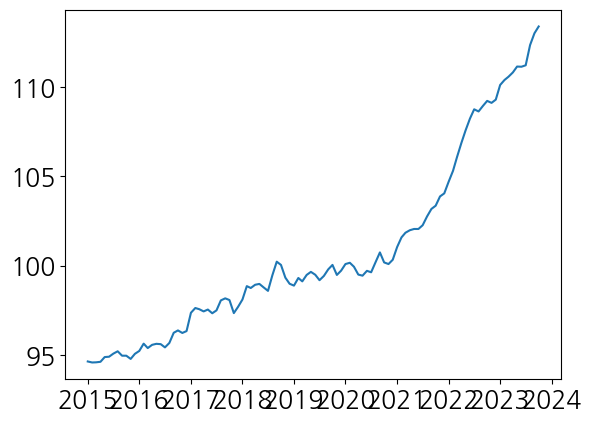

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['시점'], df['값'])
plt.show()

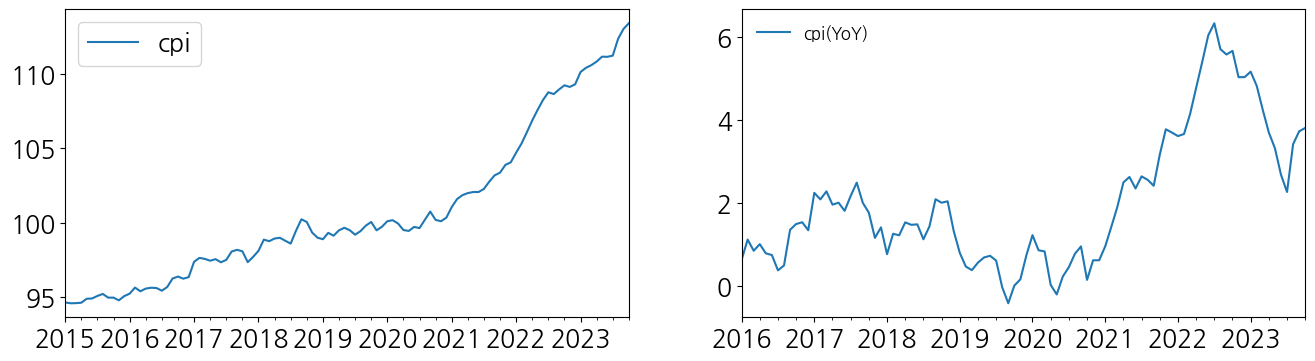

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

df_inf.plot(ax = ax[0])
(df_inf.pct_change(12)*100).loc['2016':].plot(ax = ax[1])
ax[1].legend(['cpi(YoY)'], frameon = False, fontsize = 12)

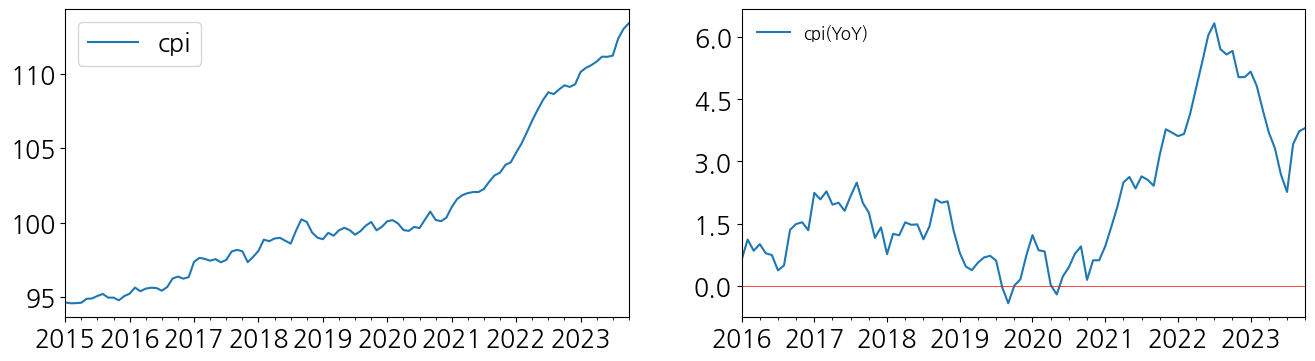

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter as FF
from matplotlib.ticker import MultipleLocator as MLo

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

df_inf.plot(ax = ax[0])
(df_inf.pct_change(12)*100).loc['2016':].plot(ax = ax[1])
ax[1].legend(['cpi(YoY)'], frameon = False, fontsize = 12)

dp2 = lambda x, p: f'{x:.1f}'
ax[1].yaxis.set_major_formatter(FF(dp2))
ax[1].yaxis.set_major_locator(MLo (1.5))

# 제로라인
ax[1].axhline(y=0, color = 'red', lw = 0.5)